# 第四阶段 A：小型 ANN 模仿与 DFN 闭环验证

## 研究问题

一个只有129个参数的小型ANN，能否用112个训练标签逼近MPC第一步电流，并以远低于在线优化的计算量，在Chen2020 DFN上完成10%到80% SOC的安全闭环？

本阶段的“通过”只表示 **ANN加安全过滤器** 完成第一版仿真验证，不表示裸ANN安全，也不表示充电速度已经优于MPC或1C基线。

## 网络、符号和安全层

输入和教师标签为

\[
x_k=[z_k,v_{1,k},v_{2,k},T_{avg,k},I_{k-1}]^{\mathsf T},
\qquad I_k^\star=\pi_{MPC}(x_k).
\]

小型网络使用

\[
5\rightarrow8\rightarrow8\rightarrow1,
\qquad \hat I_k=\pi_\theta(x_k).
\]

输入与标签的均值、标准差只由训练集计算。ANN输出先裁剪至0–10 A，再经过一步安全过滤器检查4.14 V、33.5 ℃、80% SOC和每5 s最大2 A电流变化；最后在DFN上检查4.20 V、35 ℃和10 A物理边界。

## 实验计划

1. 保持阶段3B的8/2/2条整轨迹划分；
2. 用验证集在5个L2系数和5个初始化中选模；
3. 用未参与选模的测试轨迹报告误差，并与线性岭回归比较；
4. 导出非可执行NPZ权重，用NumPy重新加载；
5. 在降阶模型和Chen2020 DFN上做闭环；
6. 同时报告安全过滤介入率、充电时间和推理加速，避免只看回归误差。

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs" / "phase4a.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

from battery_fast_charge.phase4_config import load_phase_four_a_config
from battery_fast_charge.phase4_runner import run_phase_four_a

config = load_phase_four_a_config(PROJECT_ROOT / "configs" / "phase4a.yaml")
print(f"研究：{config.study_name}")
print(f"网络：5 → {' → '.join(str(v) for v in config.network.hidden_layer_sizes)} → 1")
print(f"训练数据：{config.teacher_dataset}")

研究：chen2020_phase4a_tiny_ann_imitation
网络：5 → 8 → 8 → 1
训练数据：data/phase3b/teacher_dataset.csv


## 运行或读取正式结果

默认读取已经完成的正式结果。将 `RUN_PHASE4A` 改为 `True` 会重新训练全部候选网络并重新运行Chen2020 DFN闭环，通常需要数分钟。

In [2]:
RUN_PHASE4A = False

metrics_path = PROJECT_ROOT / "outputs" / "metrics" / "phase4a_metrics.json"
selection_path = PROJECT_ROOT / "data" / "phase4a" / "hyperparameter_selection.csv"
predictions_path = PROJECT_ROOT / "data" / "phase4a" / "offline_predictions.csv"
comparison_path = PROJECT_ROOT / "outputs" / "metrics" / "phase4a_controller_comparison.csv"

required = [metrics_path, selection_path, predictions_path, comparison_path]
if RUN_PHASE4A or any(not path.exists() for path in required):
    run_phase_four_a(config, PROJECT_ROOT)

metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
selection = pd.read_csv(selection_path)
predictions = pd.read_csv(predictions_path)
comparison = pd.read_csv(comparison_path)

## 数据隔离与选模

In [3]:
split_summary = (
    predictions[["split", "trajectory_id"]]
    .groupby("split")
    .agg(samples=("trajectory_id", "size"), trajectories=("trajectory_id", "nunique"))
)
display(split_summary)
display(selection.sort_values("validation_rmse_a").head(8).round(5))

,samples,trajectories
split,,
test,28,2
train,112,8
validation,28,2


,regularization_alpha,initialization_seed,validation_mae_a,validation_rmse_a,optimization_iterations,optimization_loss
9,0.0010,55,0.04316,0.09861,1232,0.00005
5,0.0010,11,0.05263,0.10685,1303,0.00006
7,0.0010,33,0.05273,0.10926,1130,0.00006
11,0.0100,22,0.05688,0.12668,1076,0.00037
6,0.0010,22,0.05868,0.12740,840,0.00007
10,0.0100,11,0.05795,0.13079,1113,0.00037
1,0.0001,22,0.05190,0.13447,494,0.00001
12,0.0100,33,0.06022,0.13496,899,0.00037


## 离线模仿结果

,sample_count,mae_a,rmse_a,maximum_absolute_error_a,bias_a,r2
test,28.0,0.01955,0.06909,0.34395,-0.00999,0.99779
train,112.0,0.00110,0.00185,0.00970,-0.00001,1.00000
validation,28.0,0.04316,0.09861,0.29944,-0.03346,0.99485


,model,test_MAE_A,test_RMSE_A
0,Tiny ANN,0.01955,0.06909
1,Linear ridge baseline,0.27980,0.34688


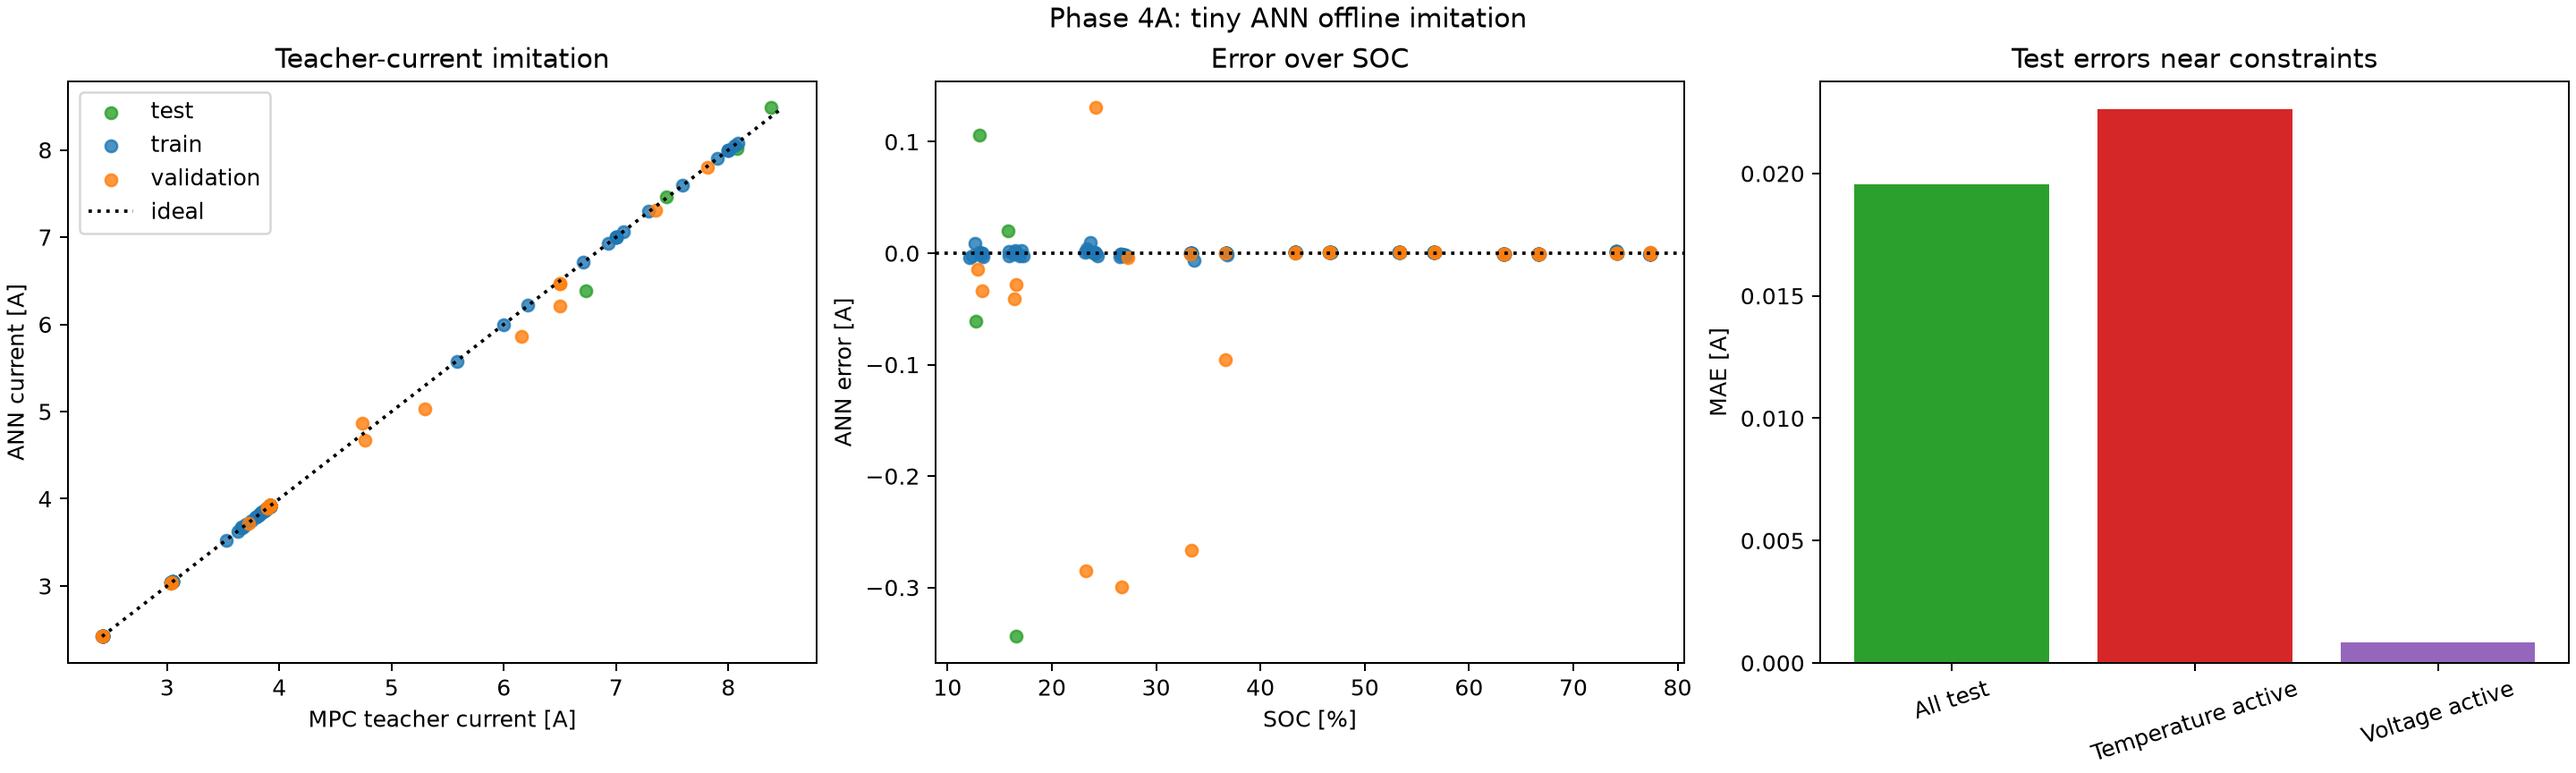

In [4]:
offline = metrics["offline_imitation"]
offline_table = pd.DataFrame(offline["split_metrics"]).T
display(offline_table.round(5))

baseline = pd.DataFrame({
    "model": ["Tiny ANN", "Linear ridge baseline"],
    "test_MAE_A": [
        offline["split_metrics"]["test"]["mae_a"],
        offline["linear_baseline"]["test_metrics"]["mae_a"],
    ],
    "test_RMSE_A": [
        offline["split_metrics"]["test"]["rmse_a"],
        offline["linear_baseline"]["test_metrics"]["rmse_a"],
    ],
})
display(baseline.round(5))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase4a_offline_imitation.png")))

测试MAE约0.020 A、RMSE约0.069 A，明显小于线性基线。但训练误差远小于验证/测试误差，说明网络已高度拟合这112个训练点；在只有两条测试轨迹的情况下，不能据此推断跨温度或跨老化泛化。

## Chen2020 DFN闭环结果

,controller,charge_time_min,maximum_voltage_v,maximum_temperature_c,maximum_current_a,success
0,Filtered 1C baseline,53.3333,4.1425,33.5024,5.0000,True
1,Constrained MPC,53.5833,4.1425,33.5167,9.8326,True
2,Tiny ANN + safety filter,55.6667,4.1425,33.5012,9.0345,True


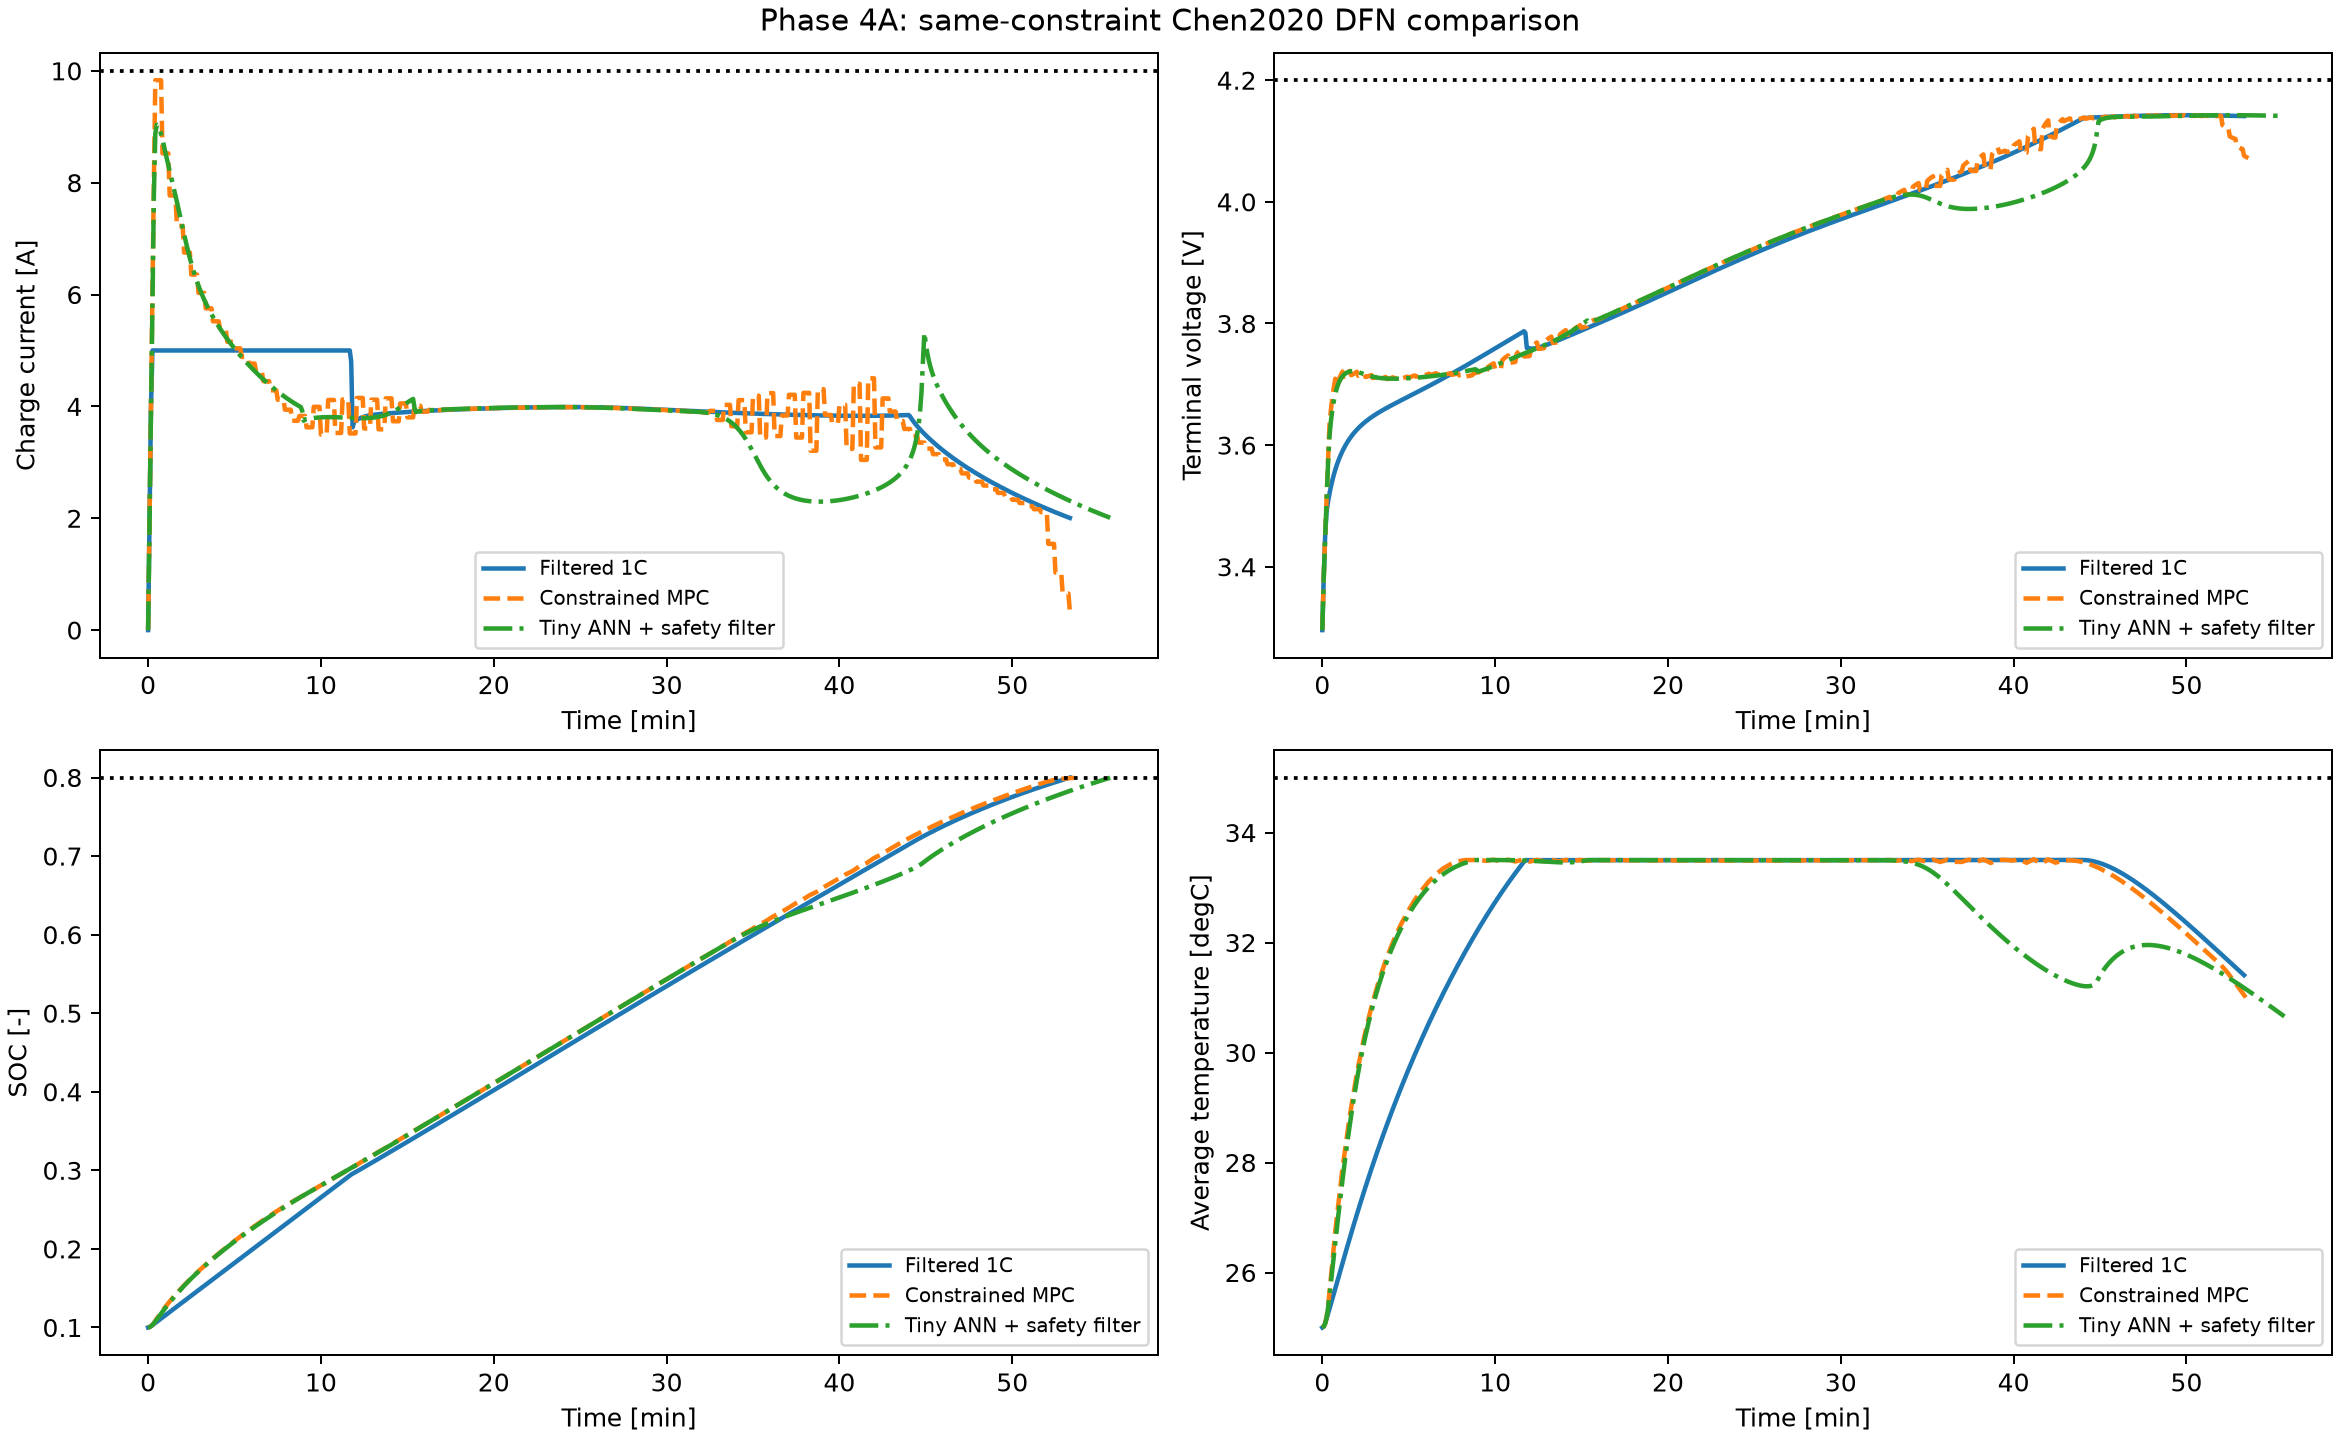

,result
ANN charge time [min],55.6667
Safety-filter interventions,336.0000
Safety-filter intervention [%],50.2994
Mean ANN inference [ms],0.1010
Speedup over MPC,5831.1522
ANN–MPC time gap [%],3.8880


In [5]:
display(comparison.round(4))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase4a_ann_dfn_comparison.png")))

dfn = metrics["ann_dfn_closed_loop"]
diagnostics = pd.Series({
    "ANN charge time [min]": dfn["charge_time_min"],
    "Safety-filter interventions": dfn["safety_filter_intervention_count"],
    "Safety-filter intervention [%]": 100 * dfn["safety_filter_intervention_fraction"],
    "Mean ANN inference [ms]": dfn["mean_ann_inference_time_ms"],
    "Speedup over MPC": metrics["inference_speedup_over_mpc"],
    "ANN–MPC time gap [%]": 100 * metrics["dfn_time_gap_fraction"],
})
display(diagnostics.to_frame("result").round(4))

绿色ANN曲线在约35–44 min明显降流并使温度下降，随后又升流。这说明闭环状态偏离了稀疏教师样本所覆盖的轨迹流形。安全过滤器在约50.3%的DFN控制周期修改了ANN请求，因此当前安全性主要来自“ANN加安全层”，不能称为裸ANN安全控制器。

ANN平均推理约0.10 ms，比MPC平均求解快约5831倍，但充电时间55.67 min，比MPC慢2.08 min，也比过滤1C慢2.33 min。

## 验收与下一步判断

In [6]:
display(pd.Series(metrics["checks"], name="passed").to_frame())

decision = pd.Series({
    "Phase 4A pipeline passed": metrics["success"],
    "Safe wrapped-ANN DFN loop passed": metrics["ann_dfn_closed_loop"]["success"],
    "Bare ANN ready for deployment": False,
    "ANN faster charging than MPC": (
        metrics["ann_dfn_closed_loop"]["charge_time_min"]
        < metrics["mpc_reference"]["charge_time_min"]
    ),
})
display(decision.to_frame("result"))

,passed
test_mae,True
test_rmse,True
temperature_active_mae,True
numpy_model_round_trip,True
reduced_closed_loop,True
dfn_closed_loop,True
dfn_time_gap,True
inference_speedup,True


,result
Phase 4A pipeline passed,True
Safe wrapped-ANN DFN loop passed,True
Bare ANN ready for deployment,False
ANN faster charging than MPC,False


## 结论

- 第一版小型ANN训练与安全包装闭环流程通过；
- 129参数网络已证明可以显著降低在线计算量；
- 50.3%的安全过滤介入率表明教师数据对闭环状态覆盖仍不足，裸ANN不应部署；
- 下一步应优先把ANN闭环访问到但教师数据稀疏的状态加入主动学习循环，再重新标注和训练；
- 如果最终目标是缩短充电时间，还必须先改进MPC教师，因为当前ANN只是在模仿一个本身未优于1C的教师。